# Project  Hospital Management Analytics Dashboard

## Notebook: SQL Joins and Exploratory Data Analysis

This notebook prepares the first analytics-ready dataset for the Hospital Management Analytics Dashboard project.

### Objectives
- Load the raw hospital tables
- Inspect structure and data quality
- Join patient, appointment, and billing tables
- Perform basic exploratory analysis
- Create a merged dataset for dashboarding in Power BI

### Tables used
- `patients.csv`
- `appointments.csv`
- `billing.csv`

### Output of this notebook
- Initial insights into the dataset
- A cleaned and merged dashboard-ready file

In [1]:
# Import the main libraries used in this notebook
import pandas as pd
import matplotlib.pyplot as plt

# Optional display settings for easier inspection
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 1. Load the raw datasets

In this section, we load the three CSV files that will be used for the first version of the dashboard.

At this stage, the goal is simply to make sure the files are readable and available in the expected project folders.

In [2]:
# Load raw datasets
patients = pd.read_csv("../data/raw/patients.csv")
appointments = pd.read_csv("../data/raw/appointments.csv")
billing = pd.read_csv("../data/raw/billing.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


## 2. Preview the tables

Before doing any joins, it is important to inspect the first few rows of each table.

This helps confirm:
- the files were loaded correctly
- the columns match expectations
- the join keys are present

In [3]:
print("Patients table")
patients.head()

Patients table


,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com


In [4]:
print("Appointments table")
appointments.head()

Appointments table


,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [5]:
print("Billing table")
billing.head()

Billing table


,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending


## 3. Inspect columns and data structure

Now we check the columns, data types, and overall shape of each table.

This step is important because in real-world datasets, column names and formats often need cleaning before analysis.

In [6]:
print("Patients shape:", patients.shape)
print("Appointments shape:", appointments.shape)
print("Billing shape:", billing.shape)

Patients shape: (50, 11)
Appointments shape: (200, 7)
Billing shape: (200, 7)


In [7]:
print("Patients columns:")
print(patients.columns.tolist())

print("\nAppointments columns:")
print(appointments.columns.tolist())

print("\nBilling columns:")
print(billing.columns.tolist())

Patients columns:
['patient_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'contact_number', 'address', 'registration_date', 'insurance_provider', 'insurance_number', 'email']

Appointments columns:
['appointment_id', 'patient_id', 'doctor_id', 'appointment_date', 'appointment_time', 'reason_for_visit', 'status']

Billing columns:
['bill_id', 'patient_id', 'treatment_id', 'bill_date', 'amount', 'payment_method', 'payment_status']


In [8]:
print("Patients info")
patients.info()

Patients info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patient_id          50 non-null     object
 1   first_name          50 non-null     object
 2   last_name           50 non-null     object
 3   gender              50 non-null     object
 4   date_of_birth       50 non-null     object
 5   contact_number      50 non-null     int64 
 6   address             50 non-null     object
 7   registration_date   50 non-null     object
 8   insurance_provider  50 non-null     object
 9   insurance_number    50 non-null     object
 10  email               50 non-null     object
dtypes: int64(1), object(10)
memory usage: 4.4+ KB


In [9]:
print("Appointments info")
appointments.info()

Appointments info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   appointment_id    200 non-null    object
 1   patient_id        200 non-null    object
 2   doctor_id         200 non-null    object
 3   appointment_date  200 non-null    object
 4   appointment_time  200 non-null    object
 5   reason_for_visit  200 non-null    object
 6   status            200 non-null    object
dtypes: object(7)
memory usage: 11.1+ KB


In [10]:
print("Billing info")
billing.info()

Billing info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bill_id         200 non-null    object 
 1   patient_id      200 non-null    object 
 2   treatment_id    200 non-null    object 
 3   bill_date       200 non-null    object 
 4   amount          200 non-null    float64
 5   payment_method  200 non-null    object 
 6   payment_status  200 non-null    object 
dtypes: float64(1), object(6)
memory usage: 11.1+ KB


## 4. Check missing values and duplicates

Before merging tables, we should identify missing values and duplicate rows.

This helps us understand:
- whether key columns are complete
- whether there are obvious data quality issues
- whether cleaning will be needed before dashboarding

In [12]:
print("Missing values in patients:")
print(patients.isnull().sum())

Missing values in patients:
patient_id            0
first_name            0
last_name             0
gender                0
date_of_birth         0
contact_number        0
address               0
registration_date     0
insurance_provider    0
insurance_number      0
email                 0
dtype: int64


In [13]:
print("Missing values in appointments:")
print(appointments.isnull().sum())

Missing values in appointments:
appointment_id      0
patient_id          0
doctor_id           0
appointment_date    0
appointment_time    0
reason_for_visit    0
status              0
dtype: int64


In [14]:
print("Missing values in billing:")
print(billing.isnull().sum())

Missing values in billing:
bill_id           0
patient_id        0
treatment_id      0
bill_date         0
amount            0
payment_method    0
payment_status    0
dtype: int64


In [15]:
print("Duplicate rows in patients:", patients.duplicated().sum())
print("Duplicate rows in appointments:", appointments.duplicated().sum())
print("Duplicate rows in billing:", billing.duplicated().sum())

Duplicate rows in patients: 0
Duplicate rows in appointments: 0
Duplicate rows in billing: 0


## 5. Standardize column names

To make analysis easier, we convert all column names to lowercase and replace spaces with underscores.

This makes coding cleaner and avoids issues later when selecting columns.

In [16]:
# Standardize column names
patients.columns = patients.columns.str.strip().str.lower().str.replace(" ", "_")
appointments.columns = appointments.columns.str.strip().str.lower().str.replace(" ", "_")
billing.columns = billing.columns.str.strip().str.lower().str.replace(" ", "_")

print("Column names standardized.")

Column names standardized.


In [17]:
print("Patients columns:")
print(patients.columns.tolist())

print("\nAppointments columns:")
print(appointments.columns.tolist())

print("\nBilling columns:")
print(billing.columns.tolist())

Patients columns:
['patient_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'contact_number', 'address', 'registration_date', 'insurance_provider', 'insurance_number', 'email']

Appointments columns:
['appointment_id', 'patient_id', 'doctor_id', 'appointment_date', 'appointment_time', 'reason_for_visit', 'status']

Billing columns:
['bill_id', 'patient_id', 'treatment_id', 'bill_date', 'amount', 'payment_method', 'payment_status']


## 6. Inspect join keys

The main join key across these tables is `patient_id`.

Before joining, we should make sure the key exists and has a compatible format in each table.

In [18]:
print("Sample patient_id values from patients:")
print(patients["patient_id"].head())

print("\nSample patient_id values from appointments:")
print(appointments["patient_id"].head())

print("\nSample patient_id values from billing:")
print(billing["patient_id"].head())

Sample patient_id values from patients:
0    P001
1    P002
2    P003
3    P004
4    P005
Name: patient_id, dtype: object

Sample patient_id values from appointments:
0    P034
1    P032
2    P048
3    P025
4    P040
Name: patient_id, dtype: object

Sample patient_id values from billing:
0    P034
1    P032
2    P048
3    P025
4    P040
Name: patient_id, dtype: object


In [19]:
print("patient_id dtype in patients:", patients["patient_id"].dtype)
print("patient_id dtype in appointments:", appointments["patient_id"].dtype)
print("patient_id dtype in billing:", billing["patient_id"].dtype)

patient_id dtype in patients: object
patient_id dtype in appointments: object
patient_id dtype in billing: object


## 7. Create analytics-ready datasets

At first, the idea was to combine appointments, patients, and billing into one table.  
However, joining `appointments` and `billing` directly on `patient_id` creates a many-to-many merge, because one patient can have multiple appointments and multiple billing records.

That kind of join duplicates rows and can produce incorrect metrics such as inflated revenue or repeated appointment records.

To keep the analysis accurate and easier to manage, this notebook creates **two separate analytics datasets**:

### Dataset 1: Appointments analytics
This dataset is built by joining:
- `appointments`
- `patients`

Join key:
- `patient_id`

This dataset will be used for:
- appointment volume
- appointment status
- patient demographics
- reasons for visit

### Dataset 2: Billing analytics
This dataset is built by joining:
- `billing`
- `patients`

Join key:
- `patient_id`

This dataset will be used for:
- total revenue
- payment method analysis
- payment status analysis
- billing-related patient insights

This approach keeps the project simple, avoids incorrect duplication, and produces cleaner inputs for Power BI.

In [34]:
appointments_analytics = appointments.merge(
    patients,
    on="patient_id",
    how="left"
)

print("Appointments analytics dataset created successfully.")
appointments_analytics.head()

Appointments analytics dataset created successfully.


,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show,Alex,Moore,M,1981-01-08,8102183595,123 Elm St,2021-10-02,MedCare Plus,INS335362,alex.moore@mail.com
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,Emily,Miller,M,1983-03-24,8720989381,123 Elm St,2023-06-19,PulseSecure,INS694319,emily.miller@mail.com
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,Robert,Wilson,M,1966-08-14,7482069727,123 Elm St,2021-09-09,HealthIndia,INS833429,robert.wilson@mail.com
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show,Emily,Williams,M,1972-05-30,7587653815,456 Oak Ave,2021-10-16,PulseSecure,INS320984,emily.williams@mail.com


In [35]:
billing_analytics = billing.merge(
    patients,
    on="patient_id",
    how="left"
)

print("Billing analytics dataset created successfully.")
billing_analytics.head()

Billing analytics dataset created successfully.


,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid,Alex,Moore,M,1981-01-08,8102183595,123 Elm St,2021-10-02,MedCare Plus,INS335362,alex.moore@mail.com
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid,Emily,Miller,M,1983-03-24,8720989381,123 Elm St,2023-06-19,PulseSecure,INS694319,emily.miller@mail.com
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed,Robert,Wilson,M,1966-08-14,7482069727,123 Elm St,2021-09-09,HealthIndia,INS833429,robert.wilson@mail.com
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending,Emily,Williams,M,1972-05-30,7587653815,456 Oak Ave,2021-10-16,PulseSecure,INS320984,emily.williams@mail.com


In [37]:
print("Appointments analytics shape:", appointments_analytics.shape)
print("Billing analytics shape:", billing_analytics.shape)

Appointments analytics shape: (200, 17)
Billing analytics shape: (200, 17)


In [38]:
appointments_analytics.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show,Alex,Moore,M,1981-01-08,8102183595,123 Elm St,2021-10-02,MedCare Plus,INS335362,alex.moore@mail.com
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,Emily,Miller,M,1983-03-24,8720989381,123 Elm St,2023-06-19,PulseSecure,INS694319,emily.miller@mail.com
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,Robert,Wilson,M,1966-08-14,7482069727,123 Elm St,2021-09-09,HealthIndia,INS833429,robert.wilson@mail.com
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show,Emily,Williams,M,1972-05-30,7587653815,456 Oak Ave,2021-10-16,PulseSecure,INS320984,emily.williams@mail.com


In [39]:
billing_analytics.head()

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid,Alex,Moore,M,1981-01-08,8102183595,123 Elm St,2021-10-02,MedCare Plus,INS335362,alex.moore@mail.com
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid,Emily,Miller,M,1983-03-24,8720989381,123 Elm St,2023-06-19,PulseSecure,INS694319,emily.miller@mail.com
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed,Robert,Wilson,M,1966-08-14,7482069727,123 Elm St,2021-09-09,HealthIndia,INS833429,robert.wilson@mail.com
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending,Emily,Williams,M,1972-05-30,7587653815,456 Oak Ave,2021-10-16,PulseSecure,INS320984,emily.williams@mail.com


## 8. Inspect the analytics datasets

After creating the two analytics-ready datasets, the next step is to inspect their structure.

At this stage, the goal is to confirm that:

- the joins worked correctly
- columns from both source tables are present
- each dataset represents the correct type of record
- there is no obvious duplication caused by the merge

### Appointments analytics dataset
This dataset should contain:
- appointment details
- visit reasons
- appointment status
- patient demographic information
- registration and insurance information

### Billing analytics dataset
This dataset should contain:
- billing details
- treatment and payment information
- payment status
- patient demographic information
- registration and insurance information

These checks help confirm that both datasets are ready for KPI exploration and further cleaning.

In [40]:
print("Duplicate rows in appointments_analytics:", appointments_analytics.duplicated().sum())
print("Duplicate rows in billing_analytics:", billing_analytics.duplicated().sum())

Duplicate rows in appointments_analytics: 0
Duplicate rows in billing_analytics: 0


## 9. Initial KPI exploration

Now that the datasets have been joined successfully, we can calculate a few initial metrics.

These KPIs are exploratory only.  
Their purpose is to help validate the dataset and identify which measures should later appear in the Power BI dashboard.

### Appointment-related KPIs
From the appointments analytics dataset, we want to understand:
- how many unique patients appear in appointments
- how many appointments were recorded
- how appointments are distributed by status

### Billing-related KPIs
From the billing analytics dataset, we want to understand:
- how many unique patients appear in billing
- the total billing amount
- how payments are distributed by payment status

In [41]:
total_patients_appointments = appointments_analytics["patient_id"].nunique()
total_appointments = appointments_analytics["appointment_id"].nunique()

print("Total unique patients in appointments dataset:", total_patients_appointments)
print("Total appointments:", total_appointments)
print("\nAppointment status distribution:")
print(appointments_analytics["status"].value_counts())

Total unique patients in appointments dataset: 48
Total appointments: 200

Appointment status distribution:
status
No-show      52
Scheduled    51
Cancelled    51
Completed    46
Name: count, dtype: int64


In [42]:
total_patients_billing = billing_analytics["patient_id"].nunique()
total_revenue = billing_analytics["amount"].sum()

print("Total unique patients in billing dataset:", total_patients_billing)
print("Total revenue:", total_revenue)
print("\nPayment status distribution:")
print(billing_analytics["payment_status"].value_counts())

Total unique patients in billing dataset: 48
Total revenue: 551249.8500000001

Payment status distribution:
payment_status
Pending    69
Failed     67
Paid       64
Name: count, dtype: int64


## 10. Visual validation and exploratory analysis

At this stage, the core KPI calculations look correct.

The next step is to visualize a few key metrics to better understand the distribution of appointments and billing activity.

These charts are exploratory and will help guide the final Power BI dashboard design.

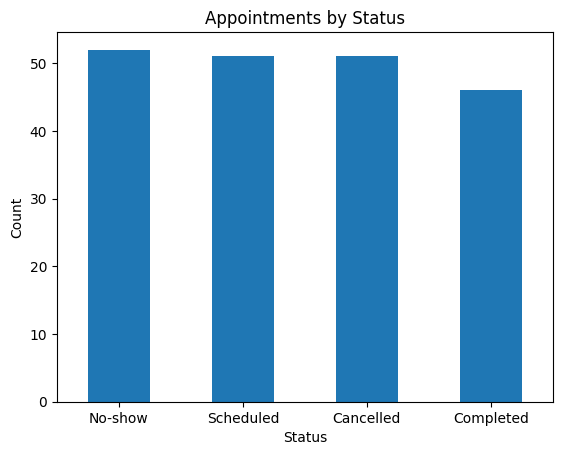

In [43]:
appointments_analytics["status"].value_counts().plot(kind="bar")
plt.title("Appointments by Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

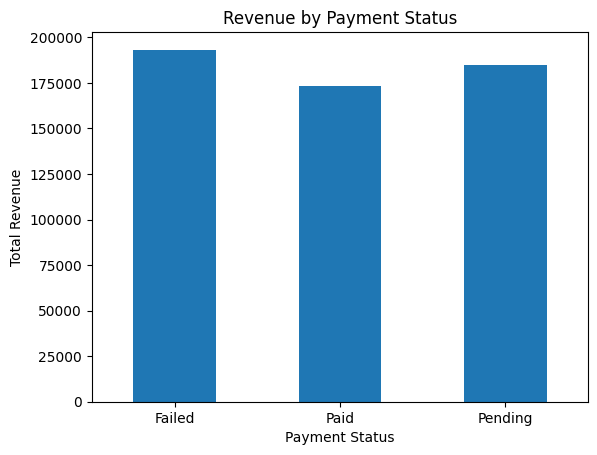

In [44]:
billing_analytics.groupby("payment_status")["amount"].sum().plot(kind="bar")
plt.title("Revenue by Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

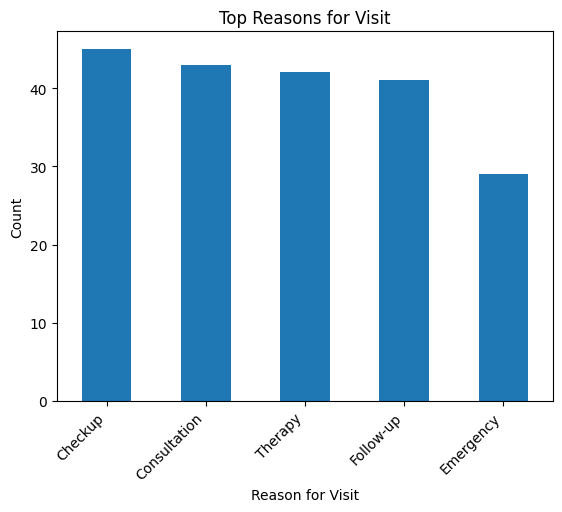

In [45]:
appointments_analytics["reason_for_visit"].value_counts().head(10).plot(kind="bar")
plt.title("Top Reasons for Visit")
plt.xlabel("Reason for Visit")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

## 11. Export processed datasets

After validating the datasets and key metrics, the final step in this notebook is to export the processed tables.

These exported files will be used directly in Power BI for dashboard development.

Two separate datasets are exported:

- `appointments_analytics_dataset.csv`
- `billing_analytics_dataset.csv`

This separation helps preserve data accuracy and avoids incorrect joins.

In [46]:
appointments_analytics.to_csv(
    "../data/processed/appointments_analytics_dataset.csv",
    index=False
)

billing_analytics.to_csv(
    "../data/processed/billing_analytics_dataset.csv",
    index=False
)

print("Both processed datasets saved successfully.")

Both processed datasets saved successfully.


## 12. Summary of progress

At this stage, the following tasks have been completed:

- Loaded raw hospital management datasets
- Inspected table structures and data quality
- Standardized column names
- Created separate analytics-ready datasets
- Avoided incorrect many-to-many joins
- Validated duplicates and KPI metrics
- Performed exploratory visualization
- Exported Power BI-ready datasets

### Key outputs
- `appointments_analytics_dataset.csv`
- `billing_analytics_dataset.csv`

### Next stage
The next phase of this project will focus on building a professional dashboard in Power BI using these processed datasets.